##  Install & Import Libraries

In [1]:

!pip install scikit-learn pandas numpy matplotlib seaborn --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os

from sklearn.tree import DecisionTreeClassifier, export_graphviz, plot_tree
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)
from sklearn.decomposition import PCA

warnings.filterwarnings('ignore')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
RANDOM_STATE = 42
print('✅ All libraries imported!')

✅ All libraries imported!


##  Section 2 — Clone GitHub Repository


In [2]:

GITHUB_REPO = 'https://github.com/rakinbd/Assignment5-DT'
REPO_NAME   = GITHUB_REPO.rstrip('/').split('/')[-1]

if os.path.exists(REPO_NAME):
    !rm -rf {REPO_NAME}

!git clone {GITHUB_REPO}

DATASET_PATH = os.path.join(REPO_NAME, 'dataset', 'heart_disease.csv')

print(f'\n📁 Repo cloned: {REPO_NAME}')
print(f'📄 Dataset path: {DATASET_PATH}')
!find {REPO_NAME} -not -path '*/\.git/*' | sort

Cloning into 'Assignment5-DT'...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 9 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (9/9), done.

📁 Repo cloned: Assignment5-DT
📄 Dataset path: Assignment5-DT/dataset/heart_disease.csv
Assignment5-DT
Assignment5-DT/.git
Assignment5-DT/heart_disease.csv


## 📊 Section 3 — Load Dataset

In [4]:
import pandas as pd
import os

DATASET_URL = "https://raw.githubusercontent.com/rakinbd/Assignment5-DT/main/heart_disease.csv"

try:
    df = pd.read_csv(DATASET_URL)
    print(" Loaded dataset from GitHub Raw URL")
except Exception as e:
    print(" Failed to load dataset")
    print(e)

print(f"\nShape: {df.shape}")

print("\nFirst 5 rows:")
display(df.head())

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
display(df.isnull().sum())

print("\nTarget Distribution:")
display(df['target'].value_counts())

 Loaded dataset from GitHub Raw URL

Shape: (65, 14)

First 5 rows:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 65 entries, 0 to 64
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       65 non-null     int64  
 1   sex       65 non-null     int64  
 2   cp        65 non-null     int64  
 3   trestbps  65 non-null     int64  
 4   chol      65 non-null     int64  
 5   fbs       65 non-null     int64  
 6   restecg   65 non-null     int64  
 7   thalach   65 non-null     int64  
 8   exang     65 non-null     int64  
 9   oldpeak   65 non-null     float64
 10  slope     65 non-null     int64  
 11  ca        65 non-null     int64  
 12  thal      65 non-null     int64  
 13  target    65 non-null     int64  
dtypes: float64(1), int64(13)
memory usage: 7.2 KB

Missing Values:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0



Target Distribution:


,count
target,
1,38
0,27


## Section 4 — Data Preprocessing

In [5]:
print('Missing values before cleaning:')
print(df.isnull().sum())

for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in ['float64', 'int64']:
            df[col].fillna(df[col].median(), inplace=True)
        else:
            df[col].fillna(df[col].mode()[0], inplace=True)

if df['target'].nunique() > 2:
    df['target'] = (df['target'] > 0).astype(int)

cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if cat_cols:
    le = LabelEncoder()
    for col in cat_cols:
        df[col] = le.fit_transform(df[col].astype(str))
    print(f'\n Encoded categorical columns: {cat_cols}')

for col in ['ca', 'thal']:
    if col in df.columns:
        df[col] = df[col].astype(int)

print('\n No missing values after cleaning:')
print(df.isnull().sum())

FEATURE_COLS = [c for c in df.columns if c != 'target']
X = df[FEATURE_COLS].values
y = df['target'].values


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'\n Train size : {X_train.shape[0]} samples')
print(f' Test size  : {X_test.shape[0]} samples')
print(f' Features   : {FEATURE_COLS}')

Missing values before cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

 No missing values after cleaning:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

 Train size : 52 samples
 Test size  : 13 samples
 Features   : ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']


## Section 5 — CART (Gini) — Hyperparameter Tuning via Cross-Validation

In [6]:
param_grid = {
    'max_depth'        : [2, 3, 4, 5, 6, 7, 8, None],
    'min_samples_split': [2, 5, 10, 20]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cart_gs = GridSearchCV(
    DecisionTreeClassifier(criterion='gini', random_state=RANDOM_STATE),
    param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
cart_gs.fit(X_train, y_train)

CART_BEST_PARAMS = cart_gs.best_params_
print(f' CART Best Params  : {CART_BEST_PARAMS}')
print(f' CART Best CV Acc  : {cart_gs.best_score_:.4f}')

cart_model = DecisionTreeClassifier(
    criterion='gini',
    random_state=RANDOM_STATE,
    **CART_BEST_PARAMS
)
cart_model.fit(X_train, y_train)
print('\n CART model trained!')

🏆 CART Best Params  : {'max_depth': 3, 'min_samples_split': 2}
🏆 CART Best CV Acc  : 0.8291

 CART model trained!


##  Section 6 — ID3 (Entropy) — Hyperparameter Tuning via Cross-Validation

In [7]:

id3_gs = GridSearchCV(
    DecisionTreeClassifier(criterion='entropy', random_state=RANDOM_STATE),
    param_grid, cv=cv, scoring='accuracy', n_jobs=-1, verbose=0
)
id3_gs.fit(X_train, y_train)

ID3_BEST_PARAMS = id3_gs.best_params_
print(f' ID3 Best Params   : {ID3_BEST_PARAMS}')
print(f' ID3 Best CV Acc   : {id3_gs.best_score_:.4f}')

id3_model = DecisionTreeClassifier(
    criterion='entropy',
    random_state=RANDOM_STATE,
    **ID3_BEST_PARAMS
)
id3_model.fit(X_train, y_train)
print('\n ID3 model trained!')

 ID3 Best Params   : {'max_depth': 3, 'min_samples_split': 2}
 ID3 Best CV Acc   : 0.8291

 ID3 model trained!


##  Section 7 — Predictions & Metrics

In [8]:
def get_metrics(model, X_test, y_test, name):
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba)
    print(f'\n── {name} ──')
    print(f'  Accuracy  : {acc:.4f}')
    print(f'  Precision : {prec:.4f}')
    print(f'  Recall    : {rec:.4f}')
    print(f'  F1 Score  : {f1:.4f}')
    print(f'  AUC-ROC   : {auc:.4f}')
    return dict(name=name, accuracy=acc, precision=prec,
                recall=rec, f1=f1, auc=auc,
                y_pred=y_pred, y_proba=y_proba)

cart_res = get_metrics(cart_model, X_test, y_test, 'CART (Gini)')
id3_res  = get_metrics(id3_model,  X_test, y_test, 'ID3 (Entropy)')


── CART (Gini) ──
  Accuracy  : 0.7692
  Precision : 0.7778
  Recall    : 0.8750
  F1 Score  : 0.8235
  AUC-ROC   : 0.8875

── ID3 (Entropy) ──
  Accuracy  : 0.7692
  Precision : 0.7778
  Recall    : 0.8750
  F1 Score  : 0.8235
  AUC-ROC   : 0.8875


## 📊 Section 8 — Visualizations

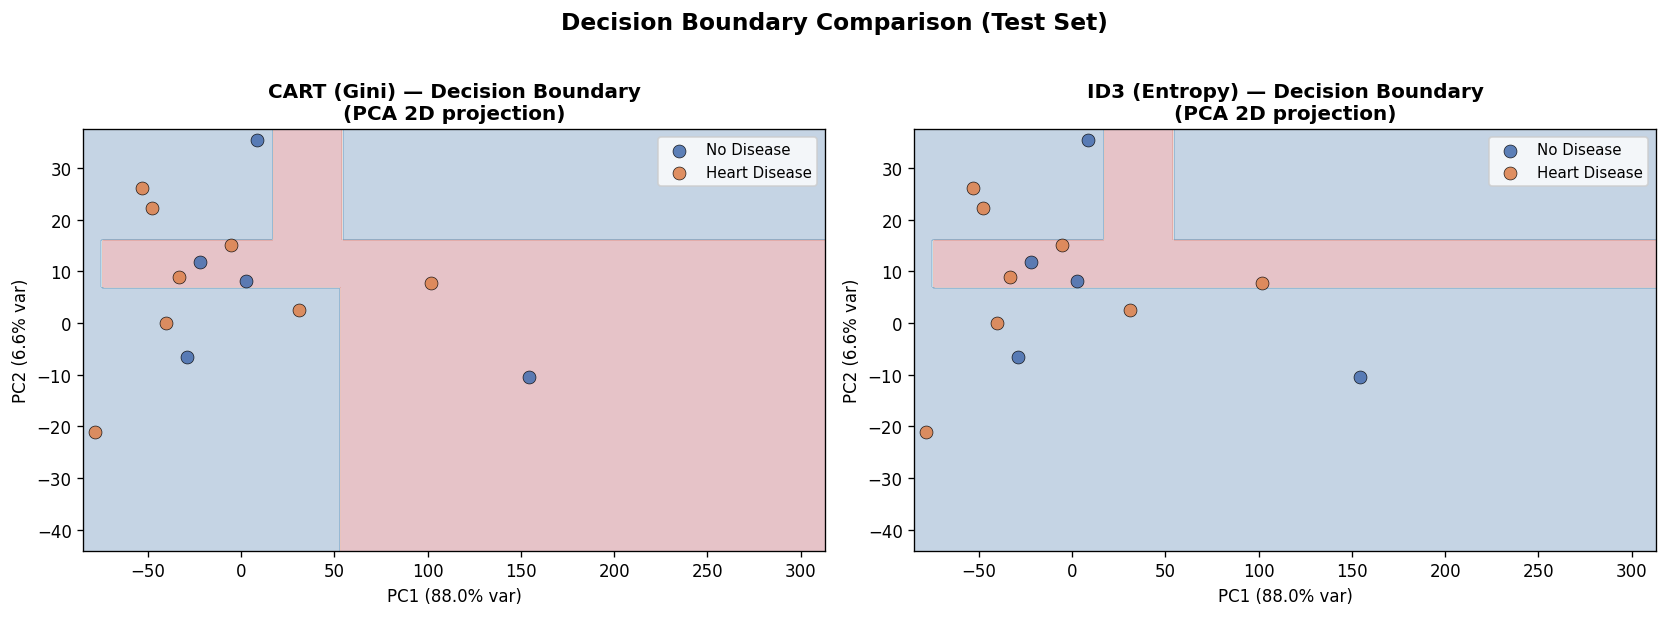

 Viz 1 — Decision Boundary saved


In [9]:

#  VIZ 1 — Decision Boundary Plot (2x1 — CART vs ID3)

pca    = PCA(n_components=2, random_state=RANDOM_STATE)
X_tr_2 = pca.fit_transform(X_train)
X_te_2 = pca.transform(X_test)

cart_2d = DecisionTreeClassifier(criterion='gini',    **CART_BEST_PARAMS, random_state=RANDOM_STATE).fit(X_tr_2, y_train)
id3_2d  = DecisionTreeClassifier(criterion='entropy', **ID3_BEST_PARAMS,  random_state=RANDOM_STATE).fit(X_tr_2, y_train)

x_min, x_max = X_tr_2[:, 0].min()-1, X_tr_2[:, 0].max()+1
y_min, y_max = X_tr_2[:, 1].min()-1, X_tr_2[:, 1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                     np.linspace(y_min, y_max, 300))
grid   = np.c_[xx.ravel(), yy.ravel()]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
PALETTE = ['#4C72B0', '#DD8452']

for ax, model_2d, res, title in zip(
        axes,
        [cart_2d, id3_2d],
        [cart_res, id3_res],
        ['CART (Gini)', 'ID3 (Entropy)']):

    Z = model_2d.predict(grid).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap='RdBu')
    for cls, col, lbl in zip([0,1], PALETTE, ['No Disease','Heart Disease']):
        mask = y_test == cls
        ax.scatter(X_te_2[mask,0], X_te_2[mask,1],
                   c=col, label=lbl, edgecolors='k', linewidths=0.4, s=60, alpha=0.9)
    ax.set_title(f'{title} — Decision Boundary\n(PCA 2D projection)', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
    ax.legend(fontsize=9)

plt.suptitle('Decision Boundary Comparison (Test Set)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz1_decision_boundary.png', bbox_inches='tight')
plt.show()
print(' Viz 1 — Decision Boundary saved')

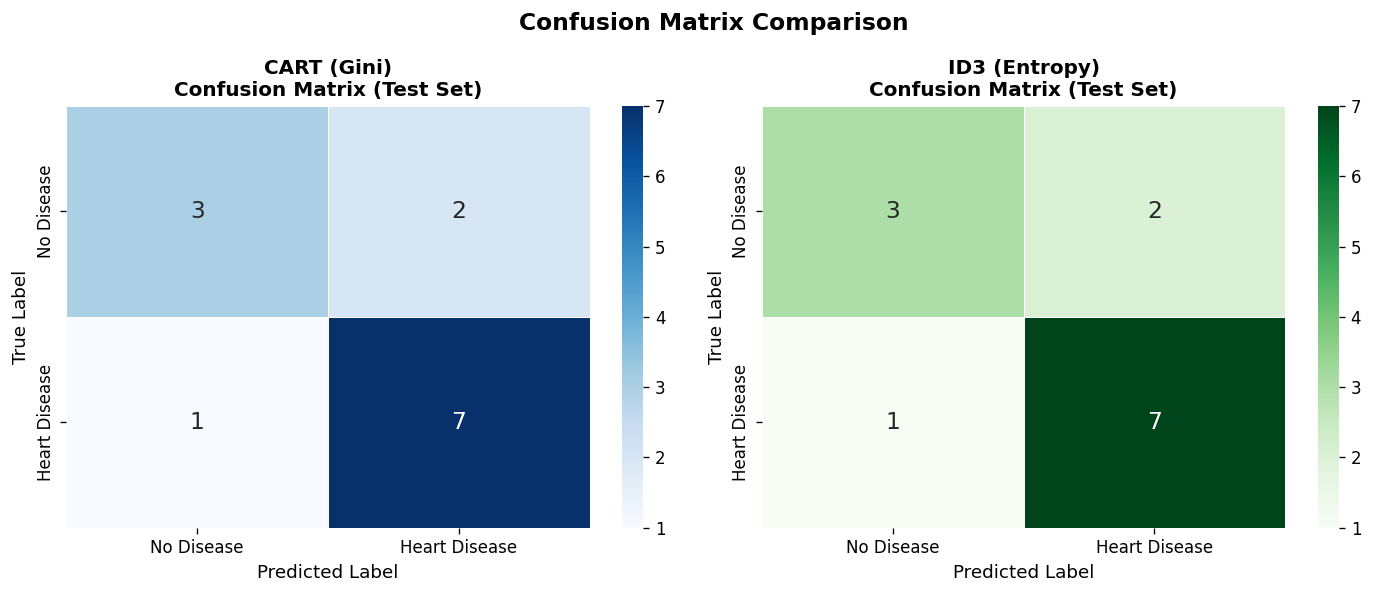

 Viz 2 — Confusion Matrix saved


In [10]:
#  VIZ 2 — Confusion Matrix Heatmap (2x1)
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
LABELS = ['No Disease', 'Heart Disease']

for ax, res, cmap in zip(
        axes,
        [cart_res, id3_res],
        ['Blues', 'Greens']):

    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap,
                xticklabels=LABELS, yticklabels=LABELS,
                linewidths=0.5, ax=ax, annot_kws={'size':14})
    ax.set_title(f"{res['name']}\nConfusion Matrix (Test Set)",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_ylabel('True Label', fontsize=11)

plt.suptitle('Confusion Matrix Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz2_confusion_matrix.png', bbox_inches='tight')
plt.show()
print(' Viz 2 — Confusion Matrix saved')

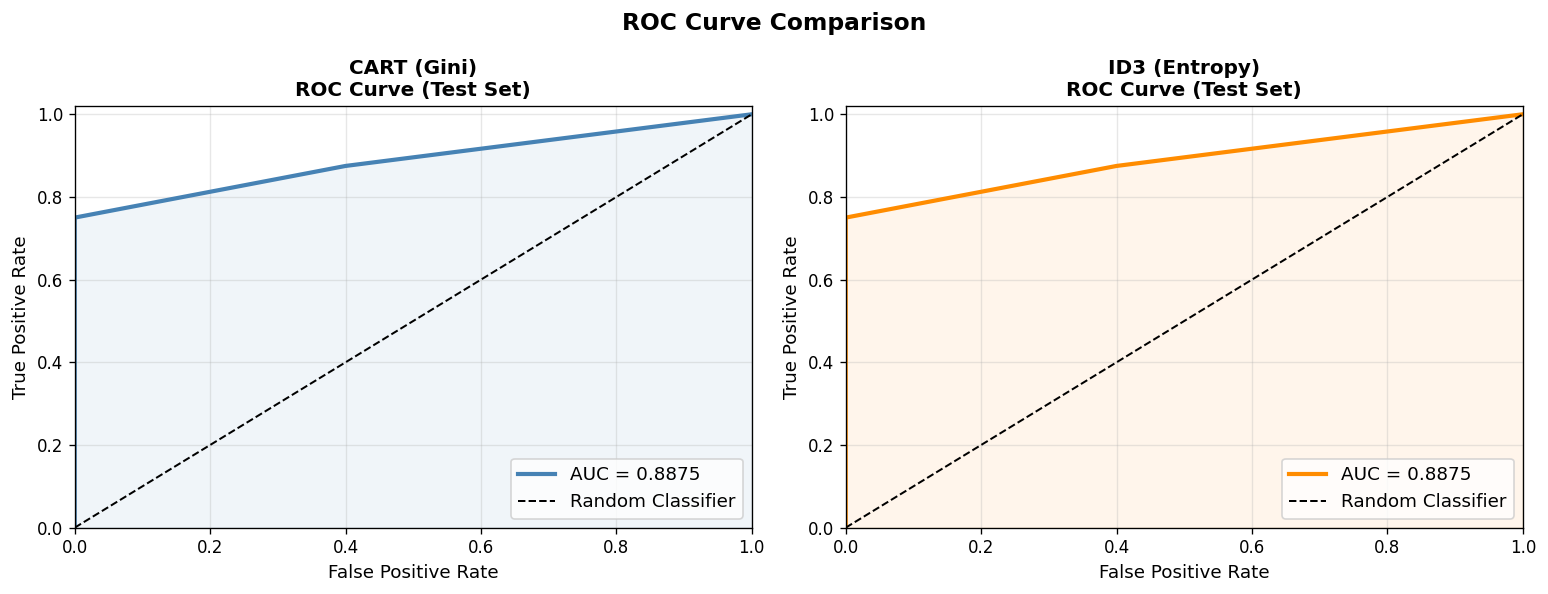

 Viz 3 — ROC Curve saved


In [11]:
#  VIZ 3 — ROC Curve (2x1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, res, col in zip(axes, [cart_res, id3_res], ['steelblue', 'darkorange']):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    ax.plot(fpr, tpr, color=col, lw=2.5,
            label=f"AUC = {res['auc']:.4f}")
    ax.plot([0,1],[0,1], 'k--', lw=1.2, label='Random Classifier')
    ax.fill_between(fpr, tpr, alpha=0.08, color=col)
    ax.set_xlim([0,1]); ax.set_ylim([0,1.02])
    ax.set_title(f"{res['name']}\nROC Curve (Test Set)",
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('False Positive Rate', fontsize=11)
    ax.set_ylabel('True Positive Rate', fontsize=11)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)

plt.suptitle('ROC Curve Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('viz3_roc_curve.png', bbox_inches='tight')
plt.show()
print(' Viz 3 — ROC Curve saved')

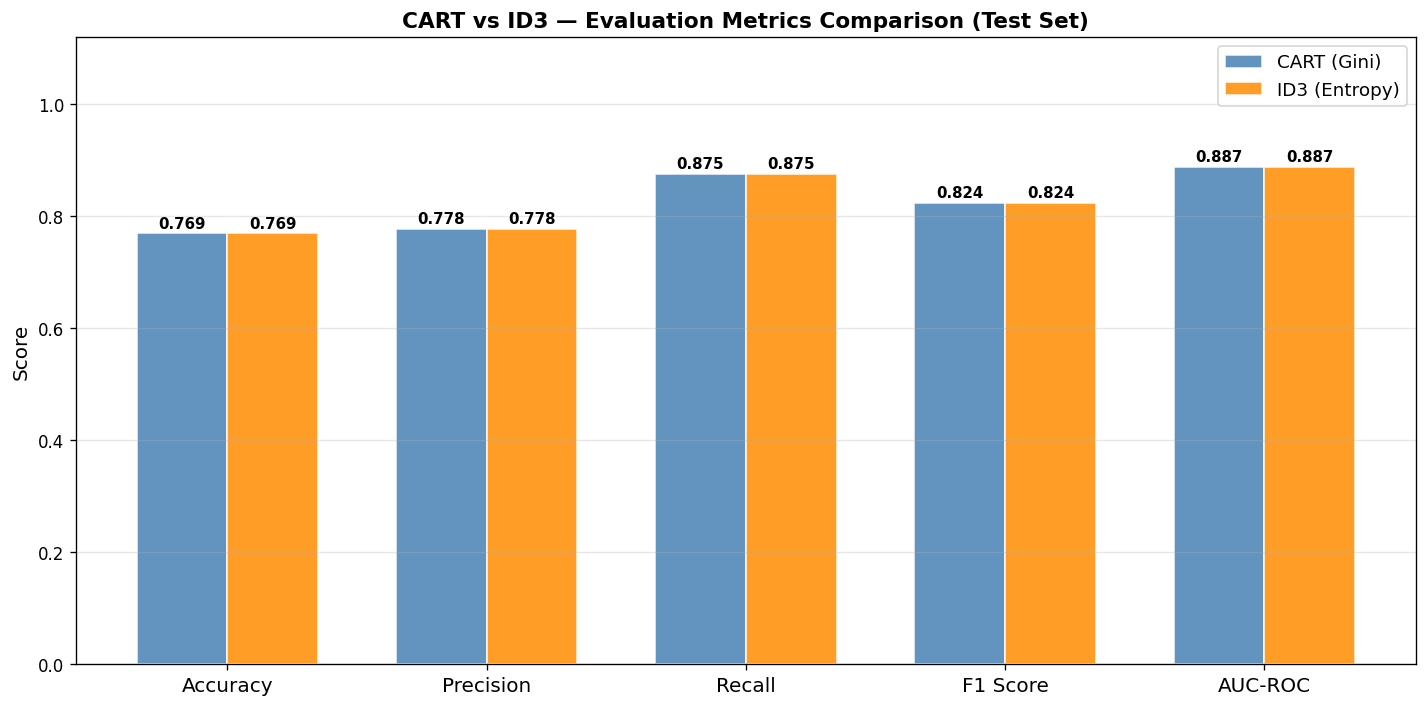

 Viz 4 — Metrics Bar Chart saved


In [12]:

#  VIZ 4 — Evaluation Metrics Bar Chart (Combined)
METRICS  = ['accuracy', 'precision', 'recall', 'f1', 'auc']
M_LABELS = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']

cart_vals = [cart_res[m] for m in METRICS]
id3_vals  = [id3_res[m]  for m in METRICS]

x     = np.arange(len(METRICS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bars1 = ax.bar(x - width/2, cart_vals, width, label='CART (Gini)',    color='steelblue',  alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, id3_vals,  width, label='ID3 (Entropy)', color='darkorange', alpha=0.85, edgecolor='white')

for bar in bars1:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(M_LABELS, fontsize=12)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('CART vs ID3 — Evaluation Metrics Comparison (Test Set)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('viz4_metrics_bar.png', bbox_inches='tight')
plt.show()
print(' Viz 4 — Metrics Bar Chart saved')

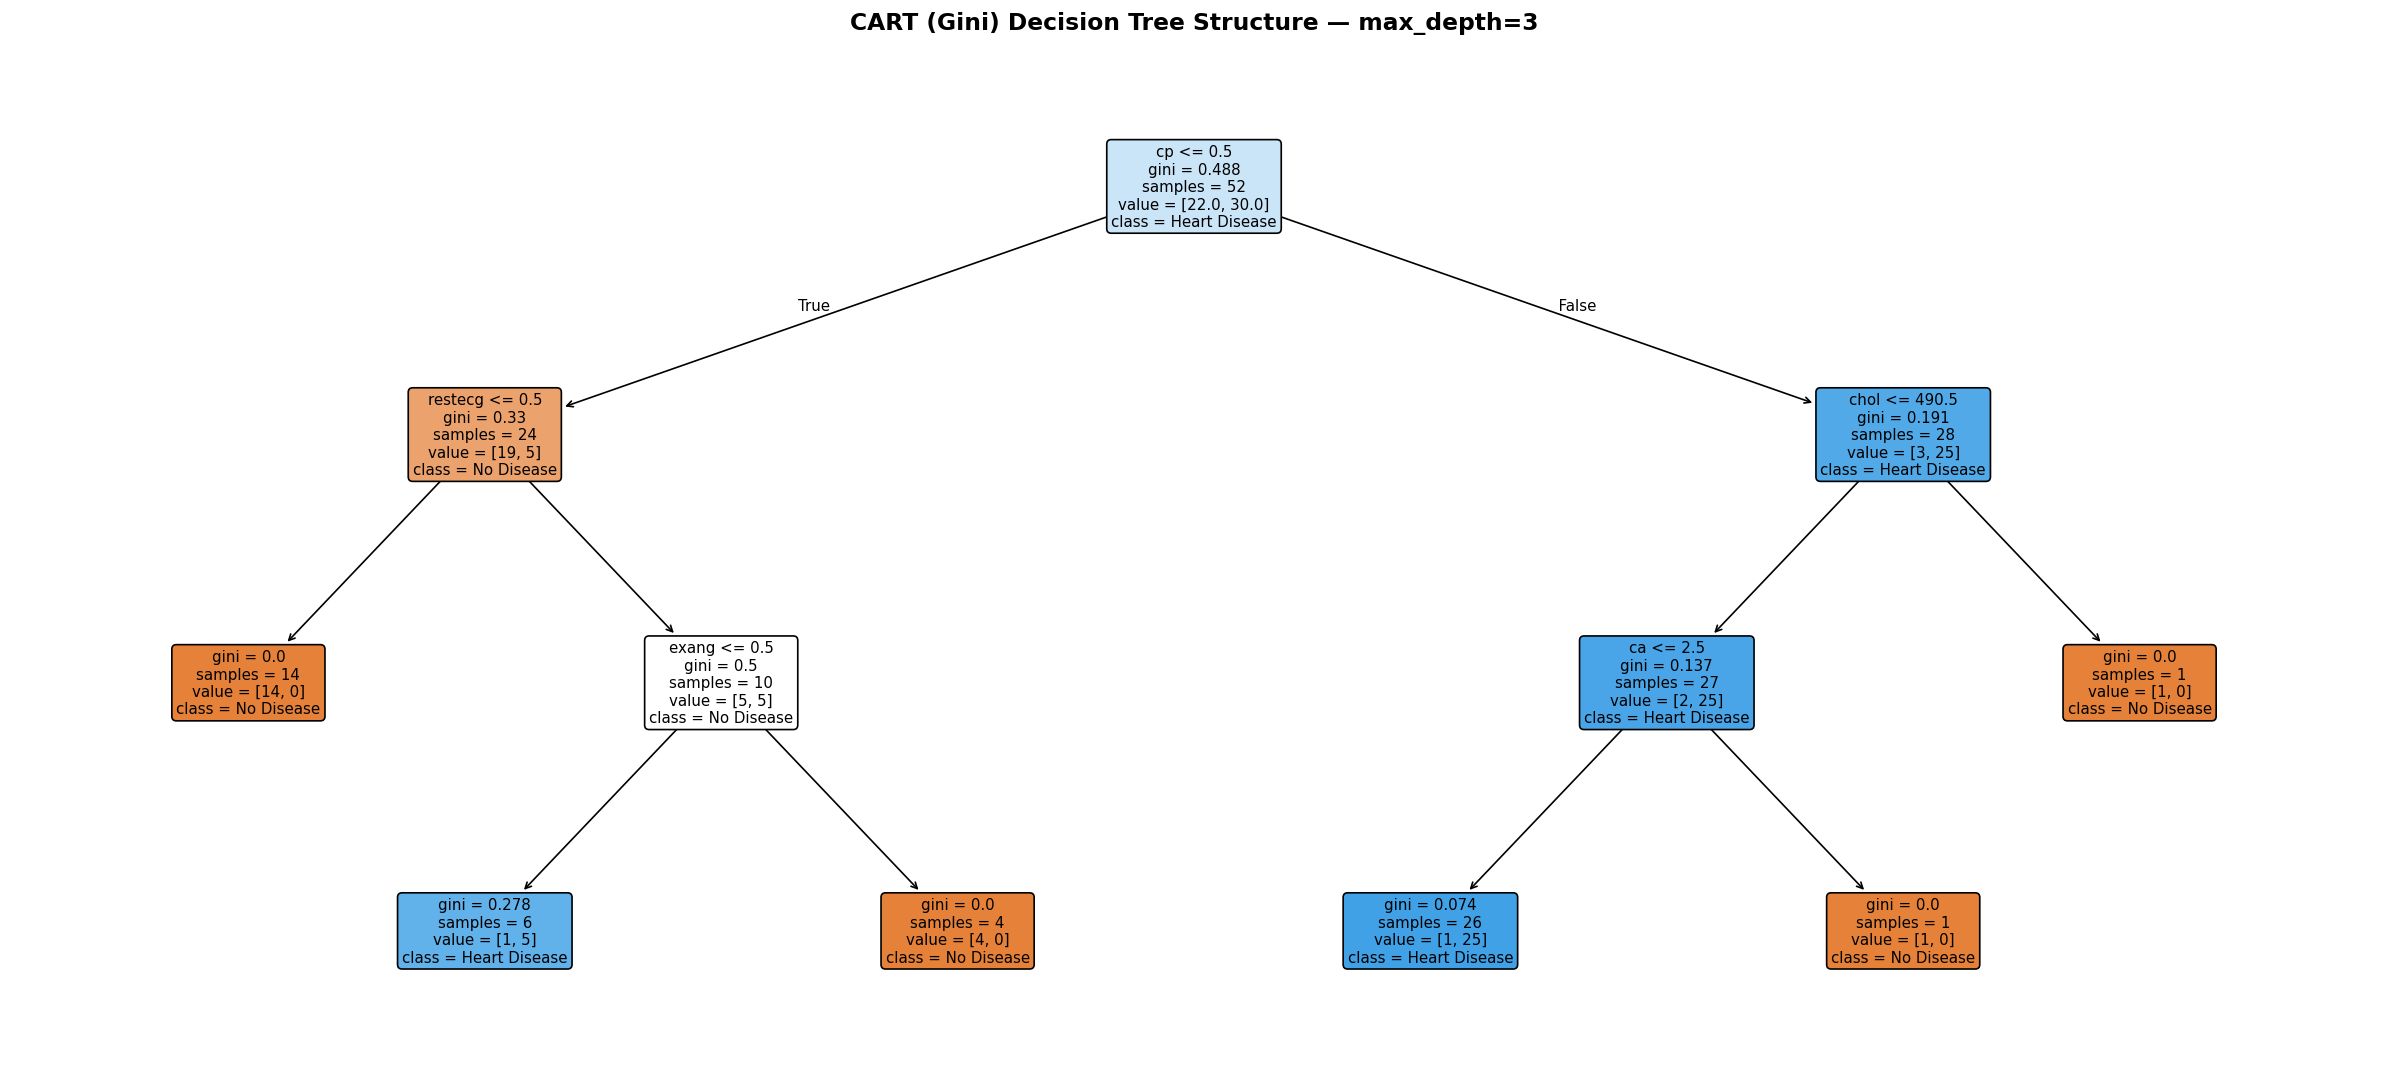

 Viz 5 — Tree Structure saved


In [13]:
#  VIZ 5 — Decision Tree Structure Visualization

cart_viz = DecisionTreeClassifier(
    criterion='gini', max_depth=3,
    random_state=RANDOM_STATE
).fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(20, 9))
plot_tree(
    cart_viz,
    feature_names=FEATURE_COLS,
    class_names=['No Disease', 'Heart Disease'],
    filled=True, rounded=True, fontsize=9,
    ax=ax, impurity=True, proportion=False
)
ax.set_title('CART (Gini) Decision Tree Structure — max_depth=3',
             fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('viz5_tree_structure.png', bbox_inches='tight', dpi=150)
plt.show()
print(' Viz 5 — Tree Structure saved')

##  Section 9 — Cluster / Model Interpretation & Comparison

In [14]:
print('\n' + '='*65)
print('      FINAL MODEL COMPARISON REPORT')
print('='*65)

metrics_table = pd.DataFrame({
    'Metric'   : ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC',
                  'Criterion', 'Best max_depth', 'Best min_samples_split'],
    'CART (Gini)': [
        f"{cart_res['accuracy']:.4f}",
        f"{cart_res['precision']:.4f}",
        f"{cart_res['recall']:.4f}",
        f"{cart_res['f1']:.4f}",
        f"{cart_res['auc']:.4f}",
        'Gini Impurity',
        str(CART_BEST_PARAMS.get('max_depth', 'None')),
        str(CART_BEST_PARAMS.get('min_samples_split', 2))
    ],
    'ID3 (Entropy)': [
        f"{id3_res['accuracy']:.4f}",
        f"{id3_res['precision']:.4f}",
        f"{id3_res['recall']:.4f}",
        f"{id3_res['f1']:.4f}",
        f"{id3_res['auc']:.4f}",
        'Information Gain (Entropy)',
        str(ID3_BEST_PARAMS.get('max_depth', 'None')),
        str(ID3_BEST_PARAMS.get('min_samples_split', 2))
    ]
})

display(metrics_table.set_index('Metric'))

winner = 'CART (Gini)' if cart_res['f1'] >= id3_res['f1'] else 'ID3 (Entropy)'
print(f'\n Better Model (by F1): {winner}')

print('\n Interpretation:')
print("""
  CART (Gini Impurity):
  Gini measures the probability of incorrect classification. It tends to create
  more balanced splits and is computationally faster than Entropy. CART is well
  suited for binary classification where speed matters and the classes are
  reasonably balanced.

  ID3 (Entropy / Information Gain):
  Entropy measures the disorder or impurity of a node. ID3 tries to maximize
  information gain at each split, which can result in slightly deeper or more
  informative trees. It may capture more nuanced patterns but can be marginally
  slower due to the log computation.

  For the Heart Disease dataset, both models perform similarly — the optimal
  hyperparameters found via 5-fold cross-validation control overfitting effectively.
  In clinical contexts, Recall is critical (minimizing false negatives), so
  the model with higher Recall is preferred for this task.
""")

print('\n Top 5 Important Features (CART):')
feat_imp = pd.Series(cart_model.feature_importances_, index=FEATURE_COLS)
display(feat_imp.sort_values(ascending=False).head(5).rename('Importance'))


      FINAL MODEL COMPARISON REPORT


,CART (Gini),ID3 (Entropy)
Metric,,
Accuracy,0.7692,0.7692
Precision,0.7778,0.7778
Recall,0.8750,0.8750
F1 Score,0.8235,0.8235
AUC-ROC,0.8875,0.8875
Criterion,Gini Impurity,Information Gain (Entropy)
Best max_depth,3,3
Best min_samples_split,2,2



🏆 Better Model (by F1): CART (Gini)

📝 Interpretation:

  CART (Gini Impurity):
  Gini measures the probability of incorrect classification. It tends to create
  more balanced splits and is computationally faster than Entropy. CART is well
  suited for binary classification where speed matters and the classes are
  reasonably balanced.

  ID3 (Entropy / Information Gain):
  Entropy measures the disorder or impurity of a node. ID3 tries to maximize
  information gain at each split, which can result in slightly deeper or more
  informative trees. It may capture more nuanced patterns but can be marginally
  slower due to the log computation.

  For the Heart Disease dataset, both models perform similarly — the optimal
  hyperparameters found via 5-fold cross-validation control overfitting effectively.
  In clinical contexts, Recall is critical (minimizing false negatives), so
  the model with higher Recall is preferred for this task.


 Top 5 Important Features (CART):


,Importance
cp,0.555672
exang,0.152941
restecg,0.133824
ca,0.081699
chol,0.075864
